## Language Modelling: Lab Assignment 
### Neural Models for Word Vector Representation

**Authors**:

- 
- 


**University**: Universidade de Santiago de Compostela

**Academic Year**: 2025-2026

---

### Table of Contents

1. [Data Preparation and Preprocessing](#1-data-preparation-and-preprocessing)

2. [Word Embedding Models](#2-word-embedding-models)
    * 2.1 [Architecture Design](#21-architecture-design)
    * 2.2 [Qualitative Analysis](#22-qualitative-analysis)
        * 2.2.1 [Semantic Similarity](#221-semantic-similarity)
        * 2.2.2 [Visualization using t-SNE](#222-visualization-using-t-sne)
3. [Downstream Text Classification](#3-downstream-text-classification)
4. [Comparative Discussion and Conclusions](#4-comprative-discussion-and-conclusions)

In [4]:
import sys

try:
    from google.colab import drive
    drive.mount('/content/drive')
    # Edit here with GoogleDrive path
    project_path = '/content/drive/MyDrive/LM/'

    if project_path not in sys.path:
        sys.path.insert(0, project_path)
    IN_COLAB = True
except:
    IN_COLAB = False
    project_path = ''

In [5]:
import os
os.environ['TF_ENABLE_ONEDNN_OPTS'] = '0'
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

import pickle
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models

from sklearn.manifold import TSNE
from sklearn.metrics.pairwise import cosine_similarity

MAX_LENGTH = 128
BATCH_SIZE = 128
EPOCHS = 20
MAX_TOKENS = 20000 # Vocabulary size
DATASET_PATH = project_path + "data/eng_news_2024_30k_sentences.txt"
SEED = 1234

np.random.seed(SEED)
tf.random.set_seed(SEED)

print(f"TensorFlow version: {tf.__version__}")
print(f"Keras version: {tf.keras.__version__}")

TensorFlow version: 2.21.0
Keras version: 3.14.1


In [6]:
# To detect gpu: module load cesga/2020 cuda/12.8.0
gpus = tf.config.list_physical_devices('GPU')

if gpus:
    print(f"Number of GPUs detected: {len(gpus)}")
    for i, gpu in enumerate(gpus):
        print(f"Device {i}: {gpu}")
else:
    print("No GPU detected. The session is currently using the CPU.")

Number of GPUs detected: 1
Device 0: PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')


## 1. Data Preparation and Preprocessing

In [7]:
vectorization_layer = tf.keras.layers.TextVectorization(
    standardize='lower_and_strip_punctuation',
    output_mode='int',
    max_tokens=MAX_TOKENS,
    output_sequence_length=None,
)

def load_corpus(file_path):
    with open(file_path, 'r', encoding='utf-8') as f:
        sentences = [line.strip() for line in f if line.strip()]

    vectorization_layer.adapt(sentences)
    return sentences

def create_training_samples(sentences, n=3):
    integer_sequences = vectorization_layer(sentences).numpy()

    X_train = []
    y_train = []

    for seq in integer_sequences:
        # Apply a mask to remove padding (token id = 0)
        # (Not needed since sequences have variable length)
        tokens = seq#[seq != 0]
        # Padding at the front
        tokens = np.concatenate([np.zeros(n),tokens])
        # Padding at the back
        tokens = np.concatenate([tokens, np.zeros(n)])

        for i in range(n, len(tokens) - n):
            context = np.concatenate((tokens[i-n:i], tokens[i+1:i+n+1]))
            target = tokens[i]

            # Exclude padding and unknown words from being targets ('': 0, '[UNK]': 1)
            if target > 1:
              context = np.concatenate((tokens[i-n:i], tokens[i+1:i+n+1]))
              X_train.append(context)
              y_train.append(target)

    return np.array(X_train), np.array(y_train)


sentences = load_corpus(DATASET_PATH)
vocab = vectorization_layer.get_vocabulary()

word_to_id = {str(word): i for i, word in enumerate(vocab)}
id_to_word = {v: k for k, v in word_to_id.items()}

# Context size n=2 produces context vectors of length 2n=4
X, y = create_training_samples(sentences, n=2)

### Helper functions

In [8]:
def seq_to_sen(sequence, id_to_word):
    if np.isscalar(sequence):
        return id_to_word[int(sequence)]
    return [id_to_word[int(i)] for i in sequence]

def save_word_representations(path, embeddings, vocab=None, label=None):
    """
    Save word embeddings and vocabulary.
    """
    if not os.path.exists(path):
        os.makedirs(path)

    # Determine the suffix: use custom label or generated timestamp
    suffix = label if label else datetime.now().strftime("%y%m%d%H%M")
    
    # Define file paths using the consistent suffix
    matrix_filename = f"embeddings_{suffix}.npy"
    vocab_filename = f"vocabulary_{suffix}.pkl"
    
    # Save the matrix
    np.save(os.path.join(path, matrix_filename), embeddings)
    #print(f"Matrix saved as: {matrix_filename}")

    # Save the vocabulary list if provide
    if vocab is not None:
        with open(os.path.join(path, vocab_filename), 'wb') as f:
            pickle.dump(vocab, f)
        #print(f"Vocabulary saved as: {vocab_filename}")

def load_word_representations(path, suffix, load_vocab=True):
    """
    Retrieves embeddings and vocabulary based on the provided identifier.
    """
    matrix_path = os.path.join(path, f"embeddings_{suffix}.npy")
    embeddings = np.load(matrix_path)
    
    vocab = None
    if load_vocab:
        vocab_path = os.path.join(path, f"vocabulary_{suffix}.pkl")
        with open(vocab_path, 'rb') as f:
            vocab = pickle.load(f)
            
    return embeddings, vocab

In [9]:
for i in range(10):
    print(f"Sentence: {seq_to_sen(X[i], id_to_word)}")
    print(f"Target: {seq_to_sen(y[i], id_to_word)}")

Sentence: ['', '', 'suggested', 'donation']
Target: 1015
Sentence: ['', '1015', 'donation', 'goes']
Target: suggested
Sentence: ['1015', 'suggested', 'goes', 'to']
Target: donation
Sentence: ['suggested', 'donation', 'to', 'falmouth']
Target: goes
Sentence: ['donation', 'goes', 'falmouth', 'land']
Target: to
Sentence: ['goes', 'to', 'land', 'trust']
Target: falmouth
Sentence: ['to', 'falmouth', 'trust', '']
Target: land
Sentence: ['falmouth', 'land', '', '']
Target: trust
Sentence: ['', '', 'lower', '[UNK]']
Target: 20000
Sentence: ['', '20000', '[UNK]', 'pride']
Target: lower


In [10]:
sentence = sentences[5]
print(f"Original sentence:  {sentence}")
sentence_int = vectorization_layer(sentence)
print(f"Sentence ids:       {sentence_int}")
word_seq = [id_to_word[int(_id)] for _id in sentence_int]
print(f"Tokenized sentence: {word_seq}")

Original sentence:  … 15 of Mt. View’s 18 regular-season games were against Class B teams.
Sentence ids:       [ 1247   432     5  5493 15248   768  7722   248    41   109  1267  2880
   770]
Tokenized sentence: ['…', '15', 'of', 'mt', 'view’s', '18', 'regularseason', 'games', 'were', 'against', 'class', 'b', 'teams']


## 2. Word-Embeddings Model

In [11]:
def plot_history_metrics(history, main_title="", save_path=None):

    plt.rcParams.update({
        "axes.facecolor": "#efefea",   # Off-white background
        "grid.color": "white",         # White grid lines
        "grid.linewidth": 1.5,
        "axes.edgecolor": "#333333",
        "axes.linewidth": 1.2,
        #"figure.facecolor": "white"
    })

    # Define color palette
    colors = {
        'train_acc': '#2070b4',  # Blue
        'val_acc': '#ffa000',    # Orange
        'train_loss': '#ca181c', # Red
        'val_loss': '#9467bd'    # Purple
    }

    epochs = range(1, len(history.history['accuracy']) + 1)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
    fig.patch.set_facecolor('white')

    fig.suptitle(main_title, fontsize=16, y=1.00)
    # Plot 1: Accuracy
    ax1.plot(epochs, history.history['accuracy'], '-o', color=colors['train_acc'],
             label='Training Accuracy', markersize=4, linewidth=1.5)
    ax1.plot(epochs, history.history['val_accuracy'], '--o', color=colors['val_acc'],
             label='Validation Accuracy', markersize=4, linewidth=1.5)

    ax1.set_title('Classification Accuracy', fontsize=13, pad=15)
    ax1.set_xlabel('Epoch', fontsize=12)
    ax1.set_ylabel('Accuracy', fontsize=12)
    ax1.grid(True)
    ax1.legend(frameon=True, facecolor='white', edgecolor='#333333', fontsize=12)

    # Plot 2: Loss
    ax2.plot(epochs, history.history['loss'], '-o', color=colors['train_loss'],
             label='Training Loss', markersize=4, linewidth=1.5)
    ax2.plot(epochs, history.history['val_loss'], '--o', color=colors['val_loss'],
             label='Validation Loss', markersize=4, linewidth=1.5)

    ax2.set_title('Sparse Categorical Cross-Entropy Loss', fontsize=13, pad=15)
    ax2.set_xlabel('Epoch', fontsize=12)
    ax2.set_ylabel('Loss', fontsize=12)
    ax2.grid(True)
    ax2.legend(frameon=True, facecolor='white', edgecolor='#333333', fontsize=12)

    plt.tight_layout()

    # Save as high-quality PDF
    if save_path is not None:
        plt.savefig(save_path, format='pdf', bbox_inches='tight', dpi=300)
        print(f"Plot saved successfully to: {save_path}")
    plt.show()


### 2.1 Architecture Design

In [12]:
def build_embedding_model(vocab_size, embedding_dim, context_window, seed=SEED):
    """
    Initializes and compiles the word embedding learning model.
    
    Args:
        vocab_size (int): Size of the vocabulary (V).
        embedding_dim (int): Dimensionality of the latent vector space (d).
        context_window (int): Total number of context words (2n).
        seed (int): Random seed for reproducibility].
        
    Returns:
        tf.keras.Model: Compiled Keras Sequential model.
    """
    # Set seeds for deterministic weight initialization
    tf.keras.utils.set_random_seed(seed)
    #tf.config.experimental.enable_op_determinism() # This slows down training considerably
    
    model = tf.keras.Sequential([
        tf.keras.layers.Input(shape=(context_window,), name="input_layer"),
        
        # Embedding Layer: Maps IDs to d-dimensional vectors
        tf.keras.layers.Embedding(
            input_dim=vocab_size, 
            output_dim=embedding_dim, 
            #mask_zero=True, 
            name="embedding_layer"
        ),
        
        # Aggregation Layer: Computes the mean vector of the context
        tf.keras.layers.GlobalAveragePooling1D(name="average_layer"),
        # Hidden Layer: Non-linear processing of context representation
        tf.keras.layers.Dense(100, activation='relu', name="hidden_layer"),
        # Output Layer: Probability distribution over the vocabulary 
        tf.keras.layers.Dense(vocab_size, activation='softmax', name="output_layer")
    ])

    model.compile(
        optimizer='adam',
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

Experiment: window_size=2, emb_dim=100
Final Epoch:         20
Training Accuracy:   0.4545
Validation Accuracy: 0.1159


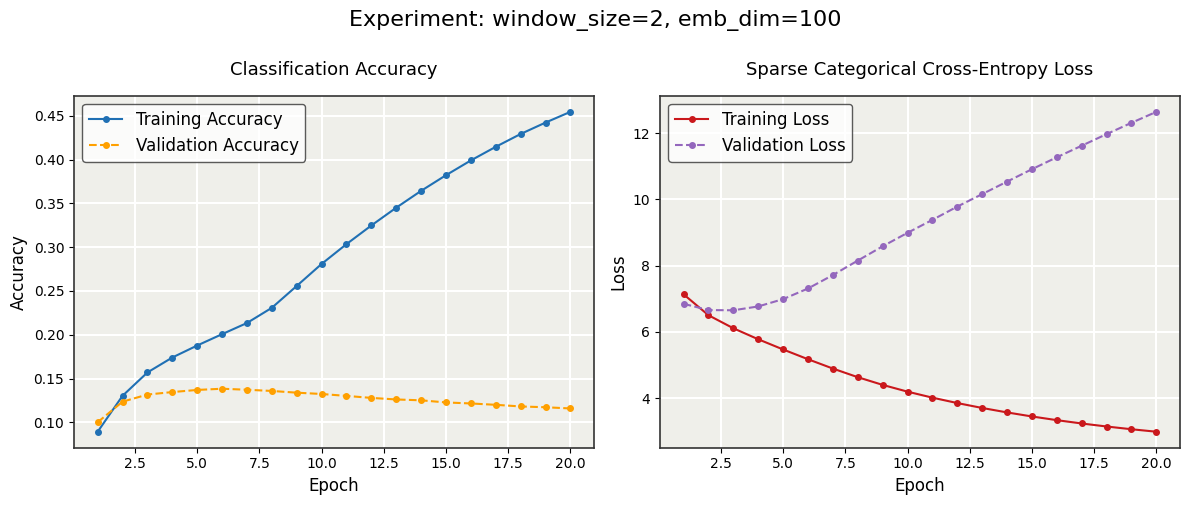

Experiment: window_size=2, emb_dim=200
Final Epoch:         20
Training Accuracy:   0.4927
Validation Accuracy: 0.1124


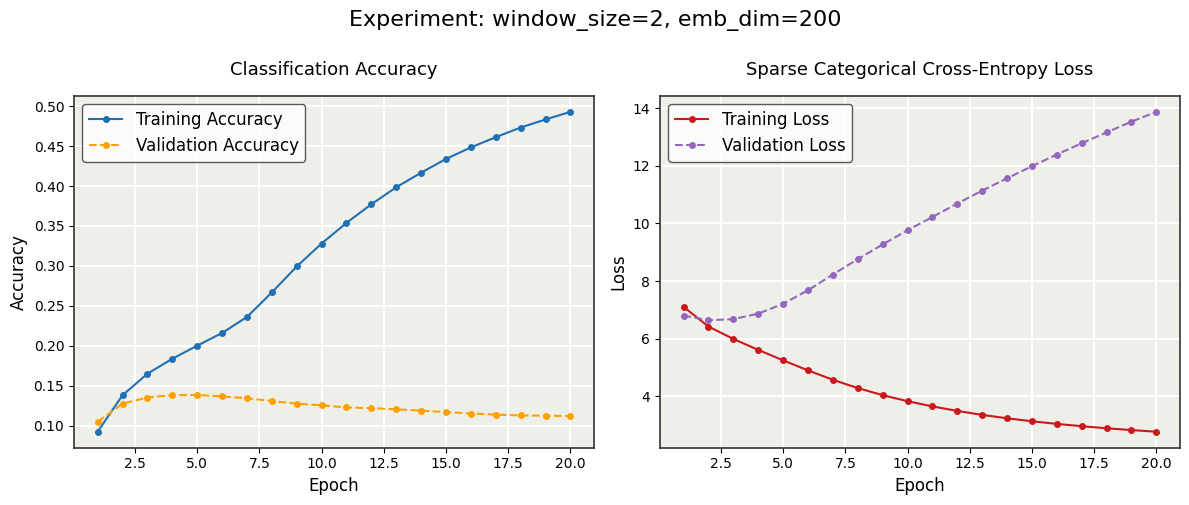

Experiment: window_size=5, emb_dim=100
Final Epoch:         20
Training Accuracy:   0.3870
Validation Accuracy: 0.0800


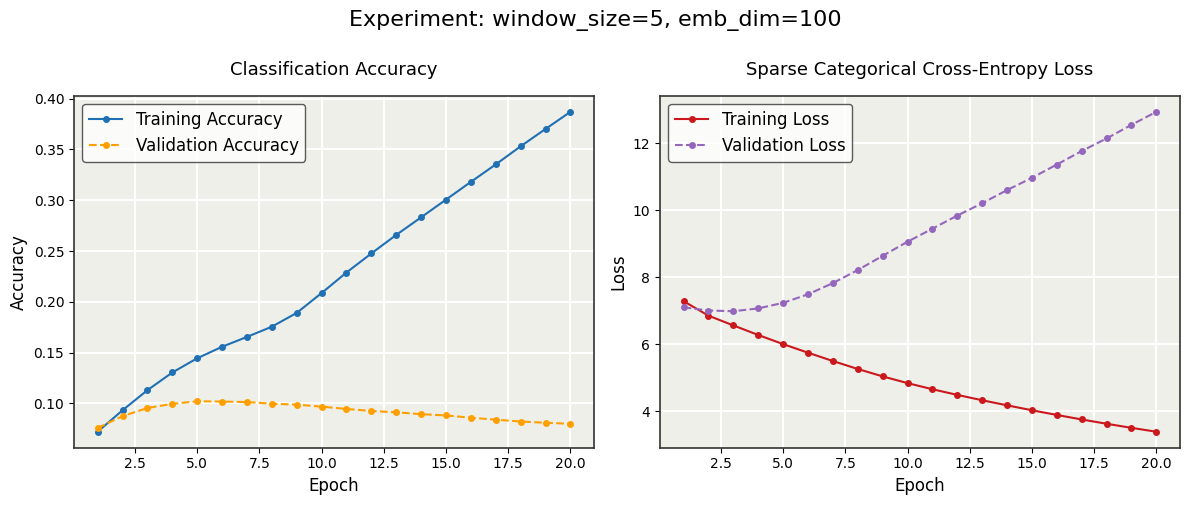

Experiment: window_size=5, emb_dim=200
Final Epoch:         20
Training Accuracy:   0.4758
Validation Accuracy: 0.0699


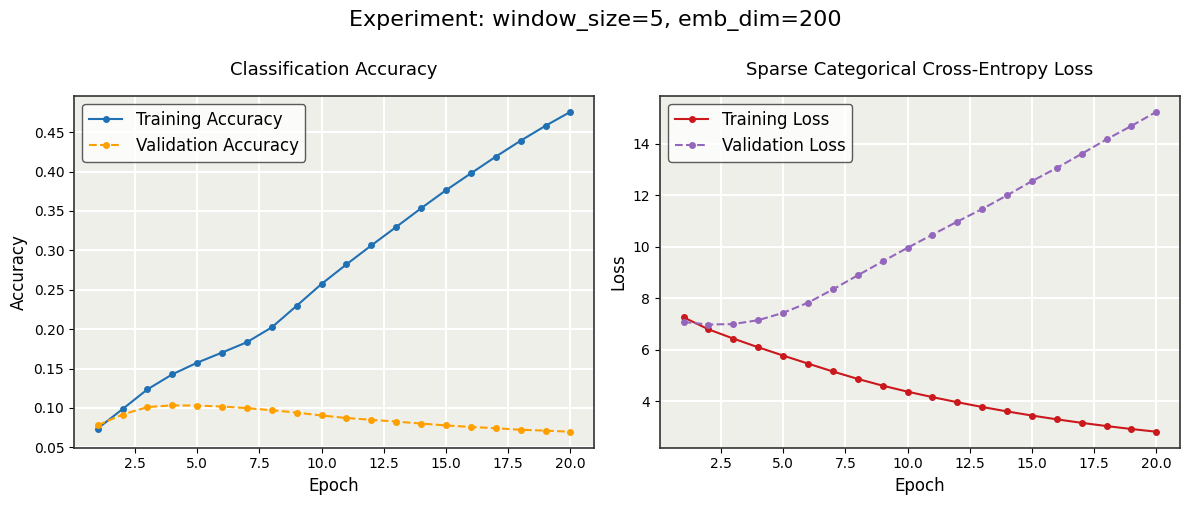

Experiment: window_size=8, emb_dim=100
Final Epoch:         20
Training Accuracy:   0.3419
Validation Accuracy: 0.0662


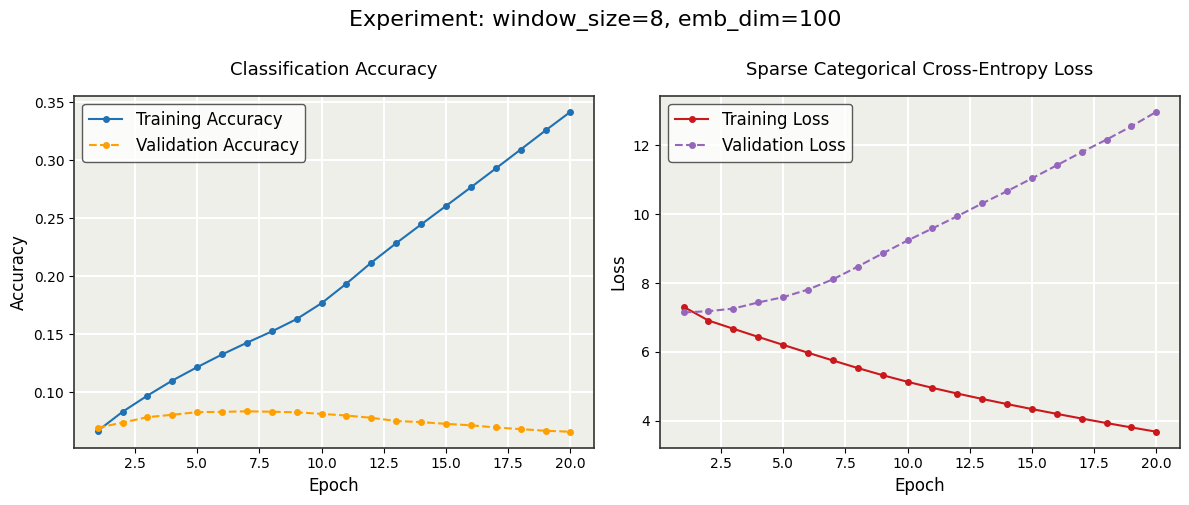

Experiment: window_size=8, emb_dim=200
Final Epoch:         20
Training Accuracy:   0.4376
Validation Accuracy: 0.0577


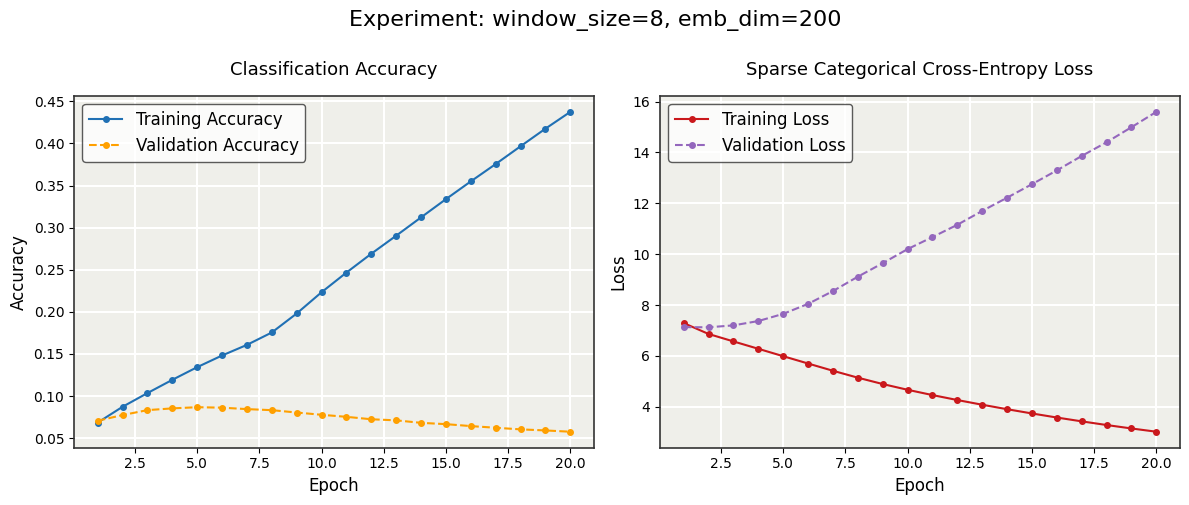

In [13]:
save_dir = project_path + "embeddings/"
os.makedirs(save_dir, exist_ok=True)

experiment_metrics = []

# Hyperparameters to test
dimensions = [100, 200]#, 300]
window_sizes = [2, 5, 8]

for w in window_sizes:
    # Get dataset with sequences of length 2*w
    X, y = create_training_samples(sentences, n=w)
    for d in dimensions:
        print(f"{'='*50}\nExperiment: window_size={w}, emb_dim={d}\n{'='*50}")
        
        # Initialize Model
        model = build_embedding_model(
            vocab_size=MAX_TOKENS, 
            embedding_dim=d, 
            context_window=2*w
        )

        # Train model
        history = model.fit(X, y, epochs=EPOCHS, batch_size=BATCH_SIZE, validation_split=0.1, shuffle=True, verbose=0)
        # Extract weights
        trained_embedding = model.get_layer('embedding_layer').get_weights()[0]
        # Qualitative evaluation
        #analyze_semantic_similarity(trained_embedding, word_to_id, vocab, target_analysis_list)
        
        print(f"Final Epoch:         {len(history.history['loss'])}")
        print(f"Training Accuracy:   {history.history['accuracy'][-1]:.4f}")
        print(f"Validation Accuracy: {history.history['val_accuracy'][-1]:.4f}")

        # Save embedding matrix to file
        label = f"w{w}_d{d}"

        experiment_metrics.append({
            "Experiment": label,
            "Dim": d,
            "Window": w,
            "Train_Acc": history.history['accuracy'][-1],
            "Val_Acc": history.history['val_accuracy'][-1],
            "Embedding_Mat": trained_embedding,
        })

        save_word_representations(save_dir, trained_embedding, label=label)
        plot_history_metrics(history, f"Experiment: window_size={w}, emb_dim={d}")

In [14]:
display(pd.DataFrame(experiment_metrics).drop(columns="Embedding_Mat"))

,Experiment,Dim,Window,Train_Acc,Val_Acc
0,w2_d100,100,2,0.454454,0.115930
1,w2_d200,200,2,0.492745,0.112377
2,w5_d100,100,5,0.386976,0.080044
3,w5_d200,200,5,0.475801,0.069852
4,w8_d100,100,8,0.341862,0.066156
5,w8_d200,200,8,0.437609,0.057669


### 2.2 Qualitative Analysis

#### 2.2.1 Semantic Similarity

In [15]:
def generate_target_comparison(target_word, experiment_ids, word_to_id, save_dir):
    """
    Generates a comparative table for a target word across multiple embedding models.
    
    Args:
        target_word (str): Word to analyze.
        experiment_ids (list): List of suffixes (e.g., ['w2_d100', 'w5_d100', ...]).
        vocab (list): Shared vocabulary list.
        save_dir (str): Directory where .npy files are stored.
    """
    if target_word not in word_to_id:
        print(f"Error: '{target_word}' not in vocabulary.")
        return None

    target_idx = word_to_id[target_word]
    comparison_data = {}

    print(f"Semantic similarity for target {target_word!r}")
    for eid in experiment_ids:
        # Load embedding matrix from disk
        file_path = os.path.join(save_dir, f"embeddings_{eid}.npy")
        embeddings = np.load(file_path)
        
        # Prepare target vector and vocabulary subset
        target_vec = embeddings[target_idx].reshape(1, -1)
        
        # Calculate cosine similarity against all words
        # Result is a (1, V) array
        sims = cosine_similarity(target_vec, embeddings).flatten()
        
        # Filter: Exclude [PAD] (0), [UNK] (1), and the target itself
        # We find top indices and filter manually to ensure exactly 10 valid neighbors
        sorted_indices = sims.argsort()[::-1]
        neighbors = []
        
        for idx in sorted_indices:
            if idx > 1 and idx != target_idx:
                neighbors.append(f"{vocab[idx]} ({sims[idx]:.3f})")
            if len(neighbors) == 10:
                break
        
        comparison_data[eid] = neighbors

    # Return as a formatted DataFrame for the report
    return pd.DataFrame(comparison_data)

In [16]:
targets = "data/target_words.txt"
target_words = load_corpus(targets)

experiment_ids = [f"w{w}_d{d}" for w in window_sizes for d in dimensions]

In [17]:
for target_word in target_words[:5]:
    display(generate_target_comparison(target_word, experiment_ids, word_to_id, save_dir))

Semantic similarity for target 'everyone'


,w2_d100,w2_d200,w5_d100,w5_d200,w8_d100,w8_d200
0,it (0.550),those (0.490),people (0.556),escobar (0.521),him (0.593),me” (0.519)
1,somebody (0.548),me (0.449),pickle (0.529),me (0.492),herman (0.588),okay (0.490)
2,olson (0.496),everybody (0.440),verma (0.505),тАУ (0.482),‘the (0.574),eats (0.481)
3,redcarpet (0.487),russia (0.427),grace (0.503),jeers (0.474),control (0.571),him (0.479)
4,lindor (0.464),me” (0.418),someone (0.497),octopus (0.473),£3m (0.568),sharon (0.474)
5,me” (0.458),someone (0.413),he (0.496),yathindra (0.467),me (0.567),marc (0.471)
6,everybody (0.451),alexei (0.408),those (0.492),them (0.467),everything (0.550),peat (0.466)
7,he (0.451),imagination (0.401),it” (0.491),slayer (0.463),partying (0.546),sure” (0.458)
8,djokovic (0.451),them (0.401),anyone (0.486),guests (0.460),it (0.546),interact (0.454)
9,she (0.450),everything (0.399),me (0.481),it” (0.454),them” (0.545),incarceration (0.454)


Semantic similarity for target 'music'


,w2_d100,w2_d200,w5_d100,w5_d200,w8_d100,w8_d200
0,skorjanec (0.453),camera (0.399),musical (0.392),me (0.380),ritual (0.497),napa (0.342)
1,interacting (0.448),“some (0.389),implications (0.390),art (0.378),nab (0.477),brodie (0.336)
2,salem (0.442),slang (0.386),science (0.388),authentic (0.377),mother’s (0.451),porter (0.334)
3,dressing (0.429),clam (0.374),fries (0.383),joyous (0.367),sliders (0.444),friend (0.334)
4,underbelly (0.417),molly (0.351),range (0.376),equally (0.354),coaches (0.423),quartet (0.332)
5,pressures (0.409),life (0.348),screenshot (0.371),inn (0.348),promise (0.420),uwazurike (0.327)
6,diseases (0.407),burnt (0.341),limping (0.367),freedom (0.340),retrieve (0.416),snippet (0.324)
7,interaction (0.407),vernon (0.335),overcrowding (0.357),luke (0.336),trove (0.414),“” (0.322)
8,coopers (0.405),competitions (0.327),uncle (0.353),gabriel (0.336),shirley (0.413),surveillance (0.321)
9,recuperating (0.402),rower (0.324),lens (0.350),sea (0.335),trash (0.413),occupation (0.318)


Semantic similarity for target 'running'


,w2_d100,w2_d200,w5_d100,w5_d200,w8_d100,w8_d200
0,work (0.449),cape (0.397),he’d (0.450),hard” (0.390),head (0.450),hunt (0.376)
1,heading (0.417),fault (0.371),artery (0.426),variety (0.371),perched (0.435),bleeding (0.370)
2,looking (0.417),falling (0.356),gibbswhite (0.418),holdover (0.365),rivalry (0.434),soon” (0.356)
3,stream (0.415),beans (0.351),mbd (0.387),coming (0.365),brightness (0.428),case (0.348)
4,chill (0.412),favour (0.346),luggage (0.383),paying (0.361),1992 (0.424),filming (0.346)
5,fork (0.409),supplier (0.341),date (0.383),mistaken (0.359),gratefully (0.421),talk (0.345)
6,play (0.409),heading (0.337),hospital (0.379),time (0.357),oneyearold (0.413),broadcast (0.343)
7,win (0.405),work (0.332),signal (0.371),tucked (0.350),reigning (0.412),zion (0.339)
8,bat (0.399),captain (0.323),desserts (0.371),doncic (0.350),naïve (0.407),colchester (0.336)
9,thumbs (0.399),life (0.316),paired (0.371),children (0.340),roe (0.406),hints (0.329)


Semantic similarity for target 'worse'


,w2_d100,w2_d200,w5_d100,w5_d200,w8_d100,w8_d200
0,more (0.476),busier (0.511),rojas (0.479),solicitation (0.385),stomach (0.494),more (0.482)
1,better (0.471),gourdes (0.490),he’ll (0.478),less (0.379),communicated (0.493),there (0.426)
2,bigger (0.467),better (0.472),publicity (0.462),dreamy (0.371),mcardle (0.492),less (0.412)
3,quite (0.462),more (0.458),decreed (0.448),30s (0.366),slot (0.486),recovered (0.411)
4,heavier (0.457),less (0.424),louder (0.439),tyson (0.366),administering (0.470),flavour (0.408)
5,normal (0.453),4g (0.388),solicitation (0.438),wherever (0.356),limit” (0.467),pedal (0.395)
6,slower (0.446),partnerships (0.386),fielding (0.423),cells (0.350),detailing (0.465),pullback (0.394)
7,longevity (0.427),tyson (0.384),80s (0.420),mayan (0.343),spark (0.460),221 (0.382)
8,alarms (0.421),energyefficient (0.377),unmistakable (0.418),unbeatable (0.342),relaxed (0.457),trafficked (0.377)
9,“better (0.416),too (0.373),shortfall (0.410),usyk (0.341),instantly (0.455),good (0.371)


Semantic similarity for target 'friday'


,w2_d100,w2_d200,w5_d100,w5_d200,w8_d100,w8_d200
0,tuesday (0.769),tuesday (0.709),tuesday (0.806),wednesday (0.732),tuesday (0.823),tuesday (0.738)
1,wednesday (0.749),thursday (0.648),monday (0.780),monday (0.719),thursday (0.791),monday (0.701)
2,monday (0.749),wednesday (0.633),thursday (0.731),tuesday (0.704),wednesday (0.785),thursday (0.689)
3,thursday (0.737),saturday (0.598),wednesday (0.723),thursday (0.660),monday (0.762),wednesday (0.682)
4,saturday (0.677),monday (0.592),saturday (0.637),saturday (0.632),saturday (0.742),seafront (0.641)
5,sunday (0.595),sunday (0.579),sunday (0.550),sunday (0.557),sunday (0.709),saturday (0.627)
6,dejean (0.498),tripadvisor (0.432),oak (0.544),x (0.473),sept (0.597),vox (0.530)
7,sept (0.471),ave (0.384),yearold (0.534),september (0.463),july (0.595),moss (0.527)
8,“well (0.458),each (0.381),aug (0.529),attacks (0.461),nov (0.558),sunday (0.525)
9,tv (0.455),discontent (0.380),pomona (0.525),ab (0.447),moss (0.542),tubes (0.484)


#### 2.2.2 Visualization using t-SNE

In [ ]:
def visualize_tsne_embeddings(words, embeddings, word_index, ax=None, title="t-SNE Visualization"):
    """
    Core function for t-SNE visualization on a specified axis.
    """

    # Filter embeddings for selected words
    indices = [word_index[word] for word in words]
    selected_embeddings = embeddings[indices]
    
    # Configure t-SNE parameters for consistency
    perplexity = min(5, len(words) - 1)
    tsne = TSNE(n_components=2, perplexity=perplexity, random_state=0, max_iter=1000)
    reduced_embeddings = tsne.fit_transform(selected_embeddings)
    
    # Utilize provided axis or create a new figure
    if ax is None:
        fig, ax = plt.subplots(figsize=(10, 10))
        
    for i, word in enumerate(words):
        if word in word_index:
            ax.scatter(reduced_embeddings[i, 0], reduced_embeddings[i, 1])
            ax.annotate(word, xy=(reduced_embeddings[i, 0], reduced_embeddings[i, 1]),
                        xytext=(5, 2), textcoords='offset points', ha='right', va='bottom')
    
    ax.set_title(title, fontsize=13)

    ax.grid(True, linestyle='--', alpha=0.6)

def visualize_comparison(words, embeddings_before, embeddings_after, word_index, title="", filename=None):
    """
    Generates a side-by-side comparison of embeddings before and after training.
    """
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 10))
    fig.suptitle(title, fontsize=18)

    # Plot 1: Initial state (Random weights)
    visualize_tsne_embeddings(words, embeddings_before, word_index, ax=ax1, title="Before Training (Random)")
    
    # Plot 2: Final state (Trained weights)
    visualize_tsne_embeddings(words, embeddings_after, word_index, ax=ax2, title="After Training (Final)")
    
    plt.tight_layout()
    if filename:
        plt.savefig(filename)
        print(f"Comparison plot saved to: {filename}")
    plt.show()

In [19]:
experiment_ids

['w2_d100', 'w2_d200', 'w5_d100', 'w5_d200', 'w8_d100', 'w8_d200']

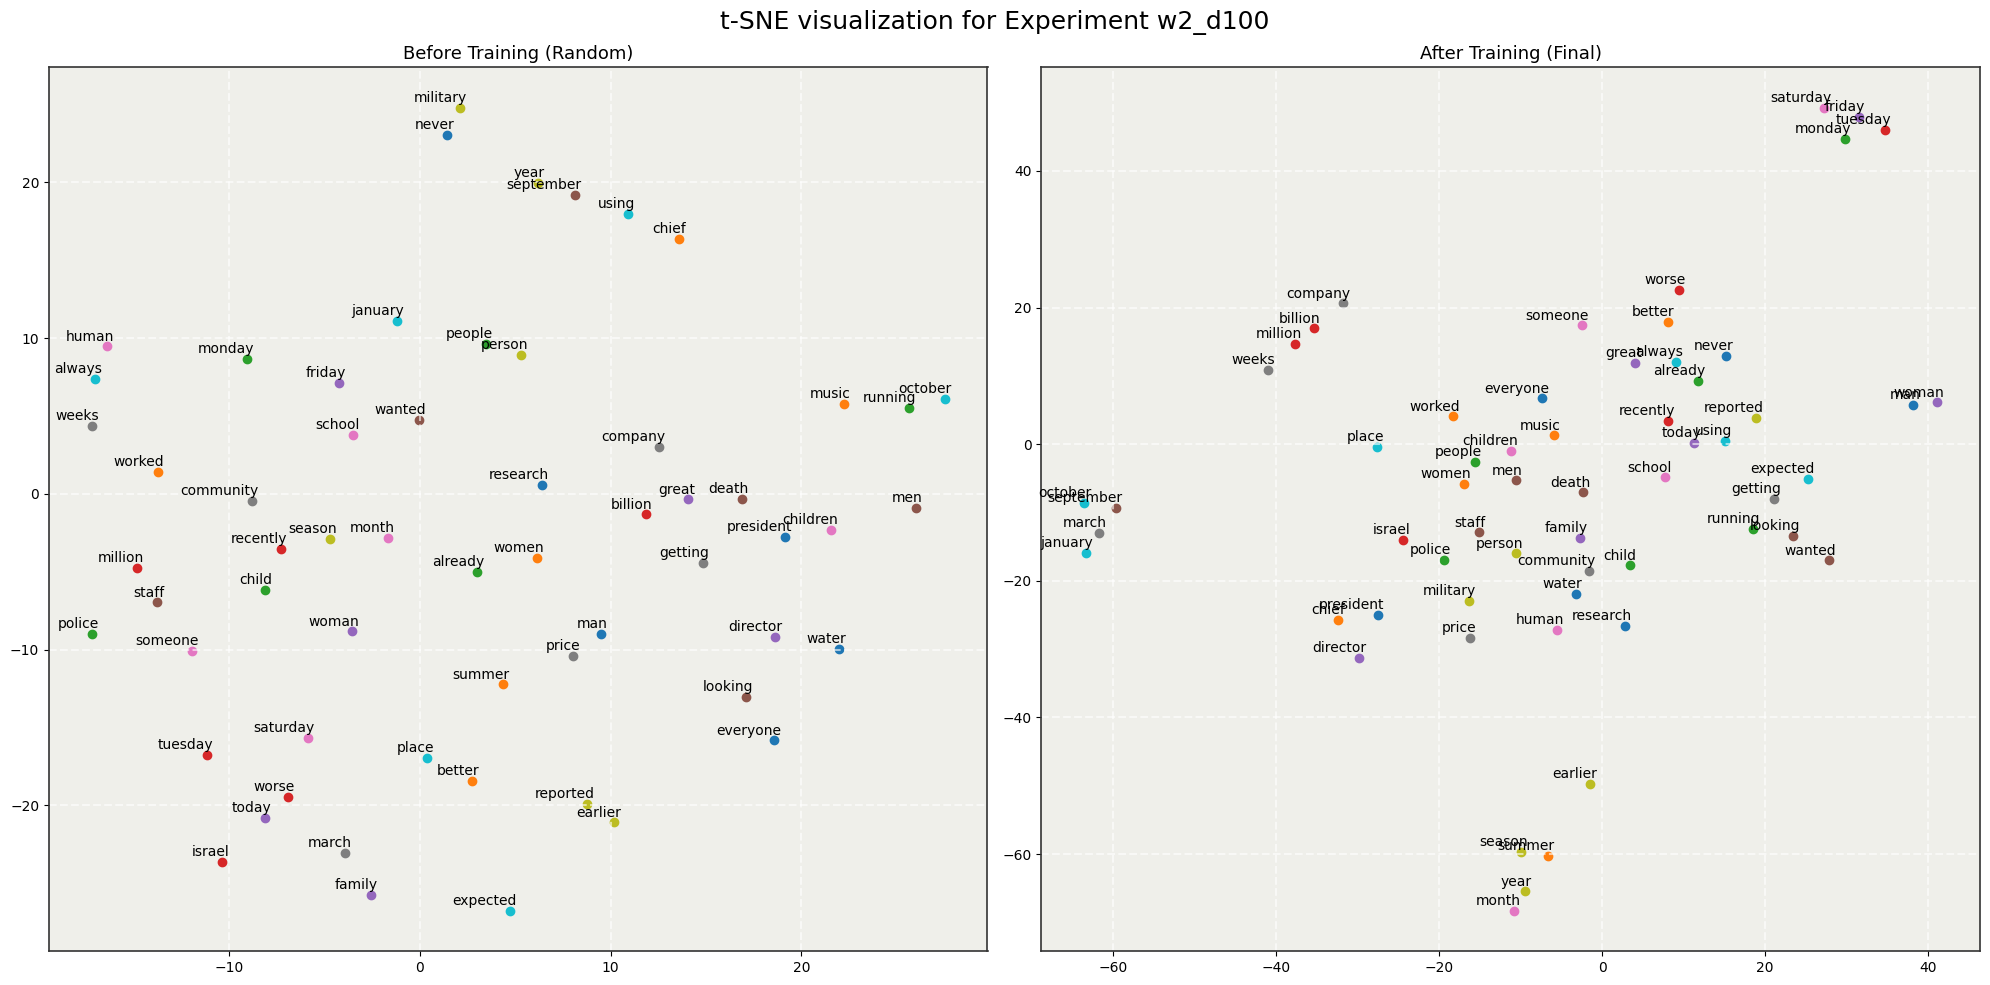

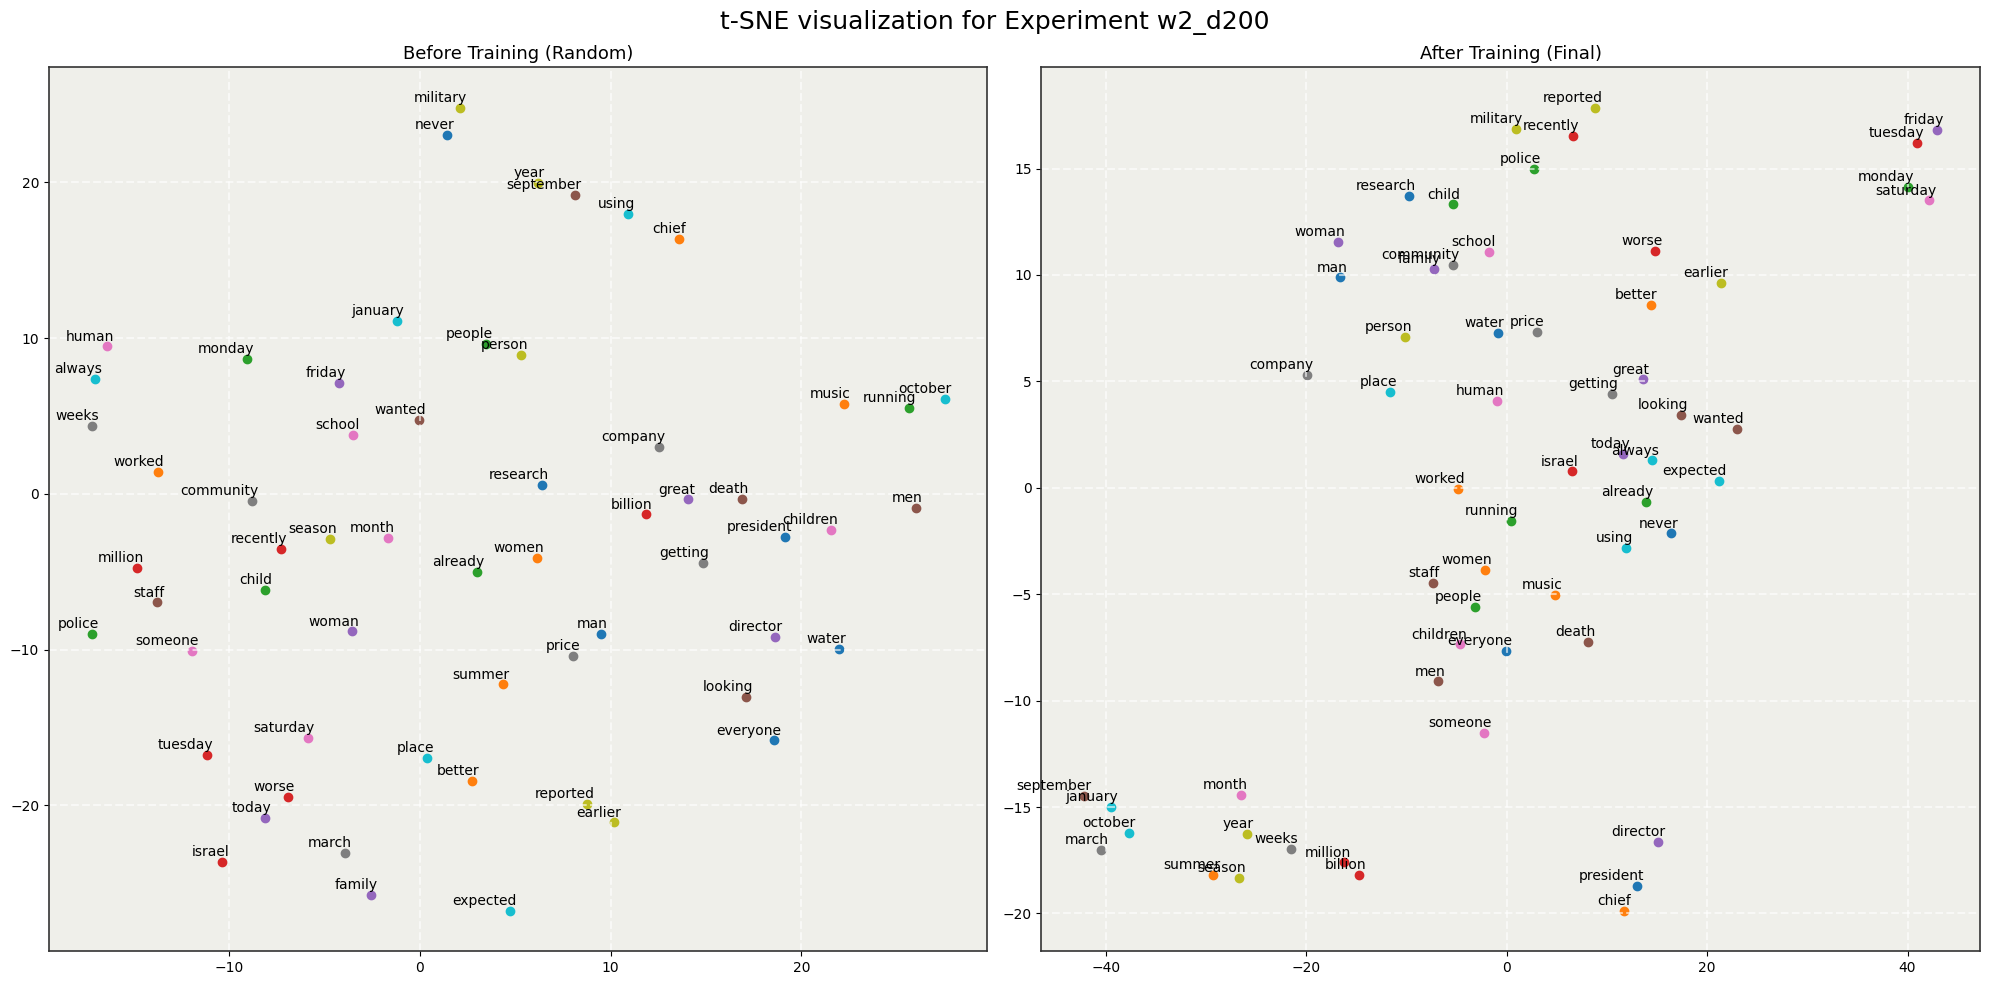

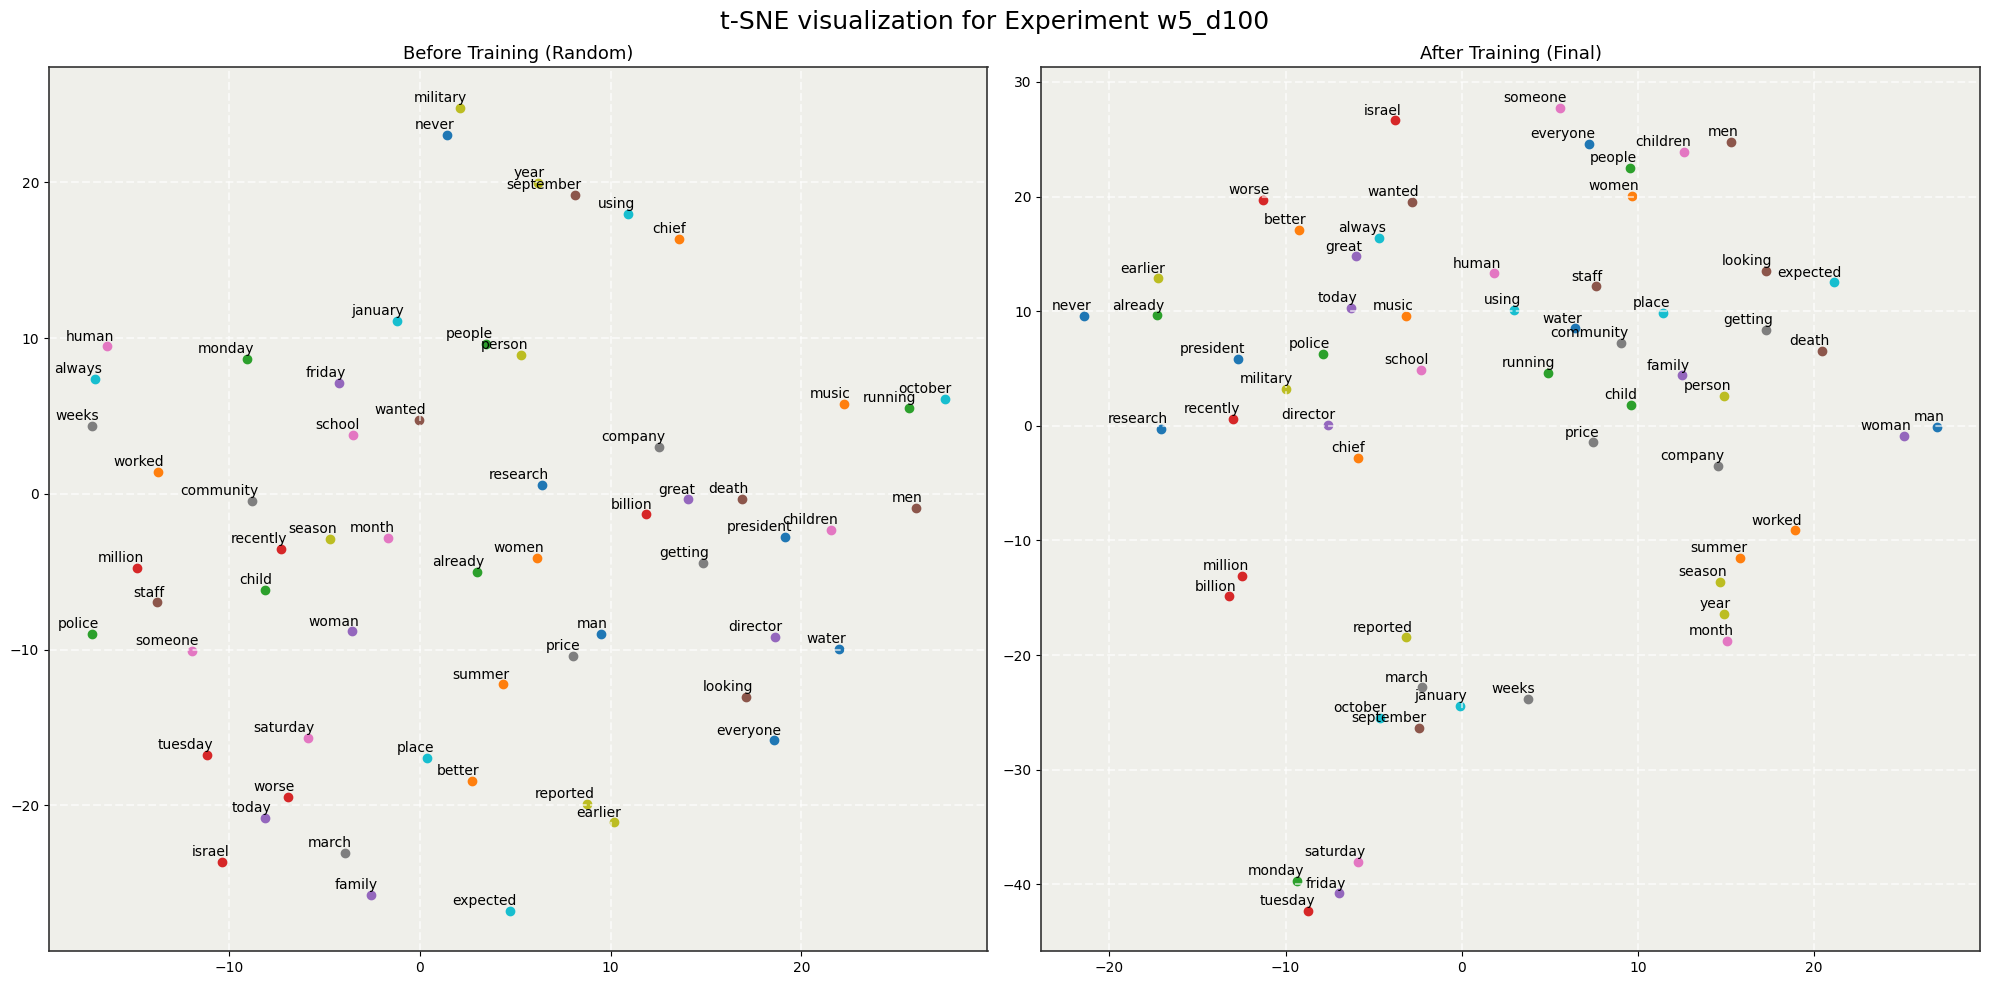

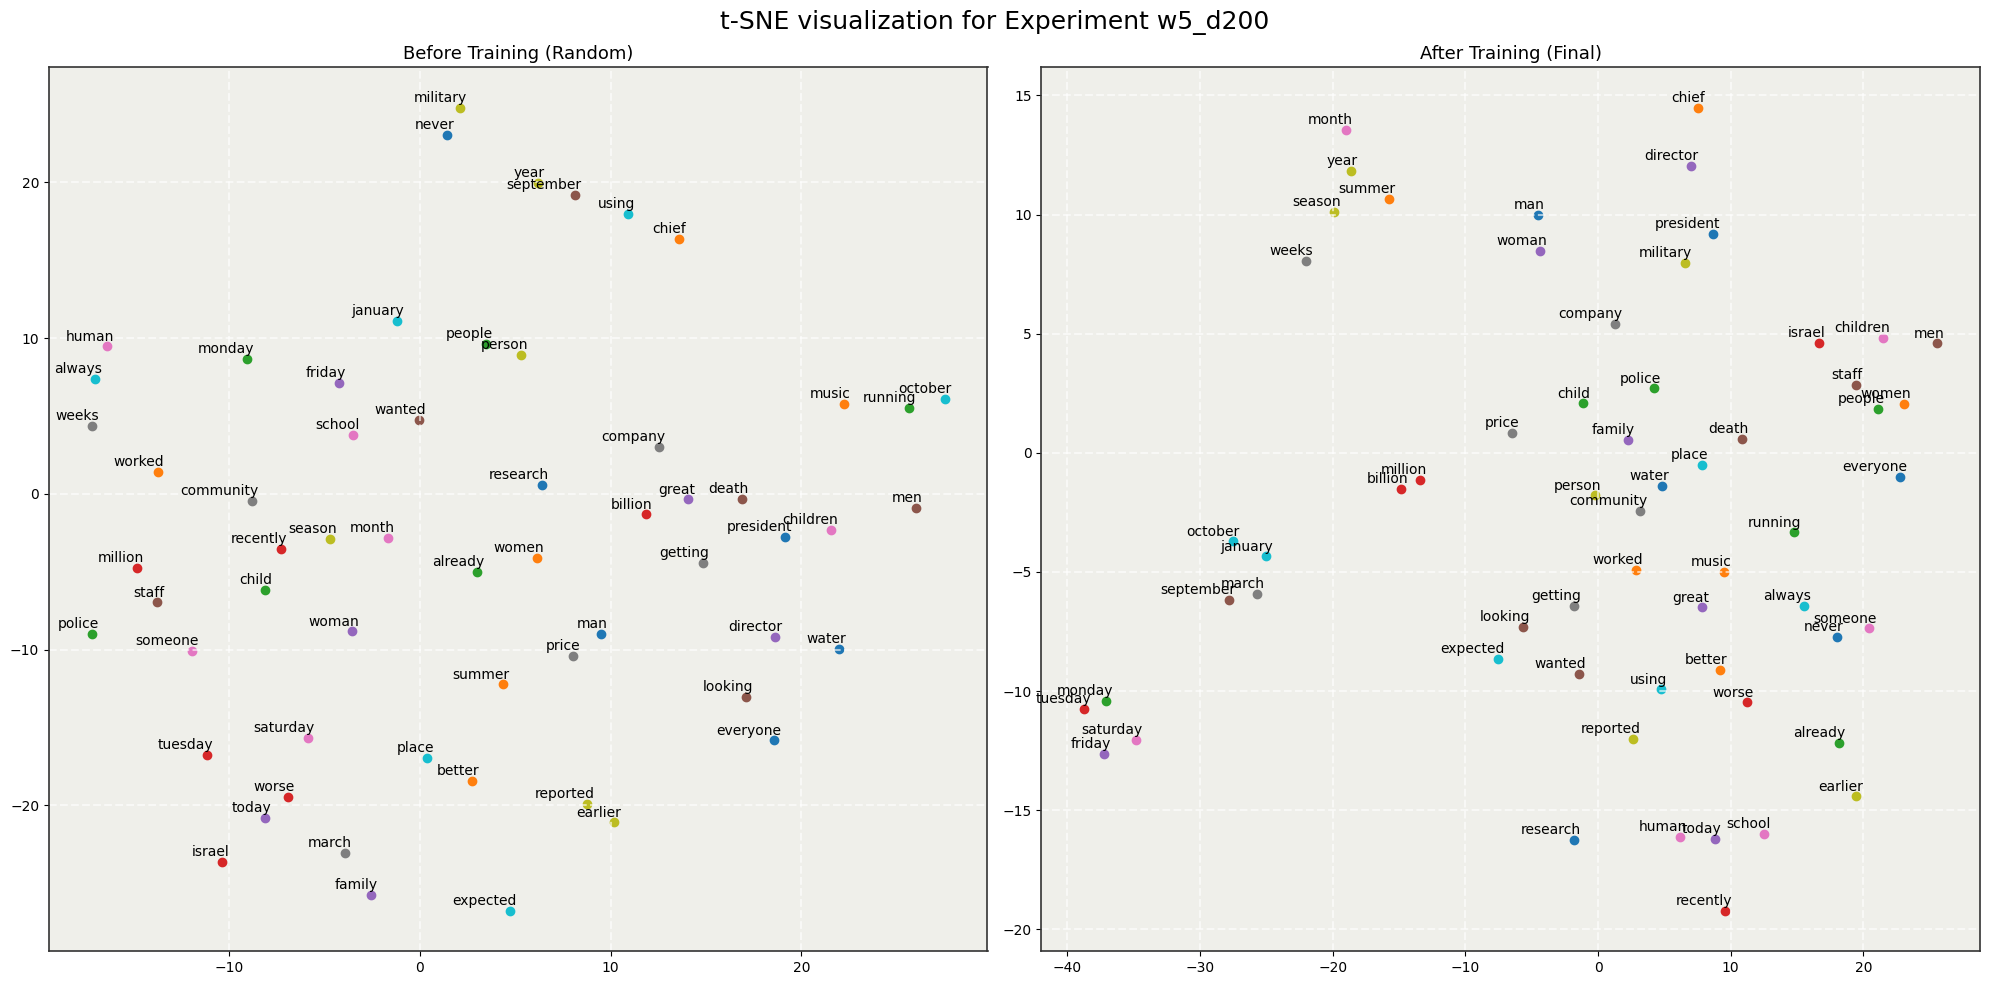

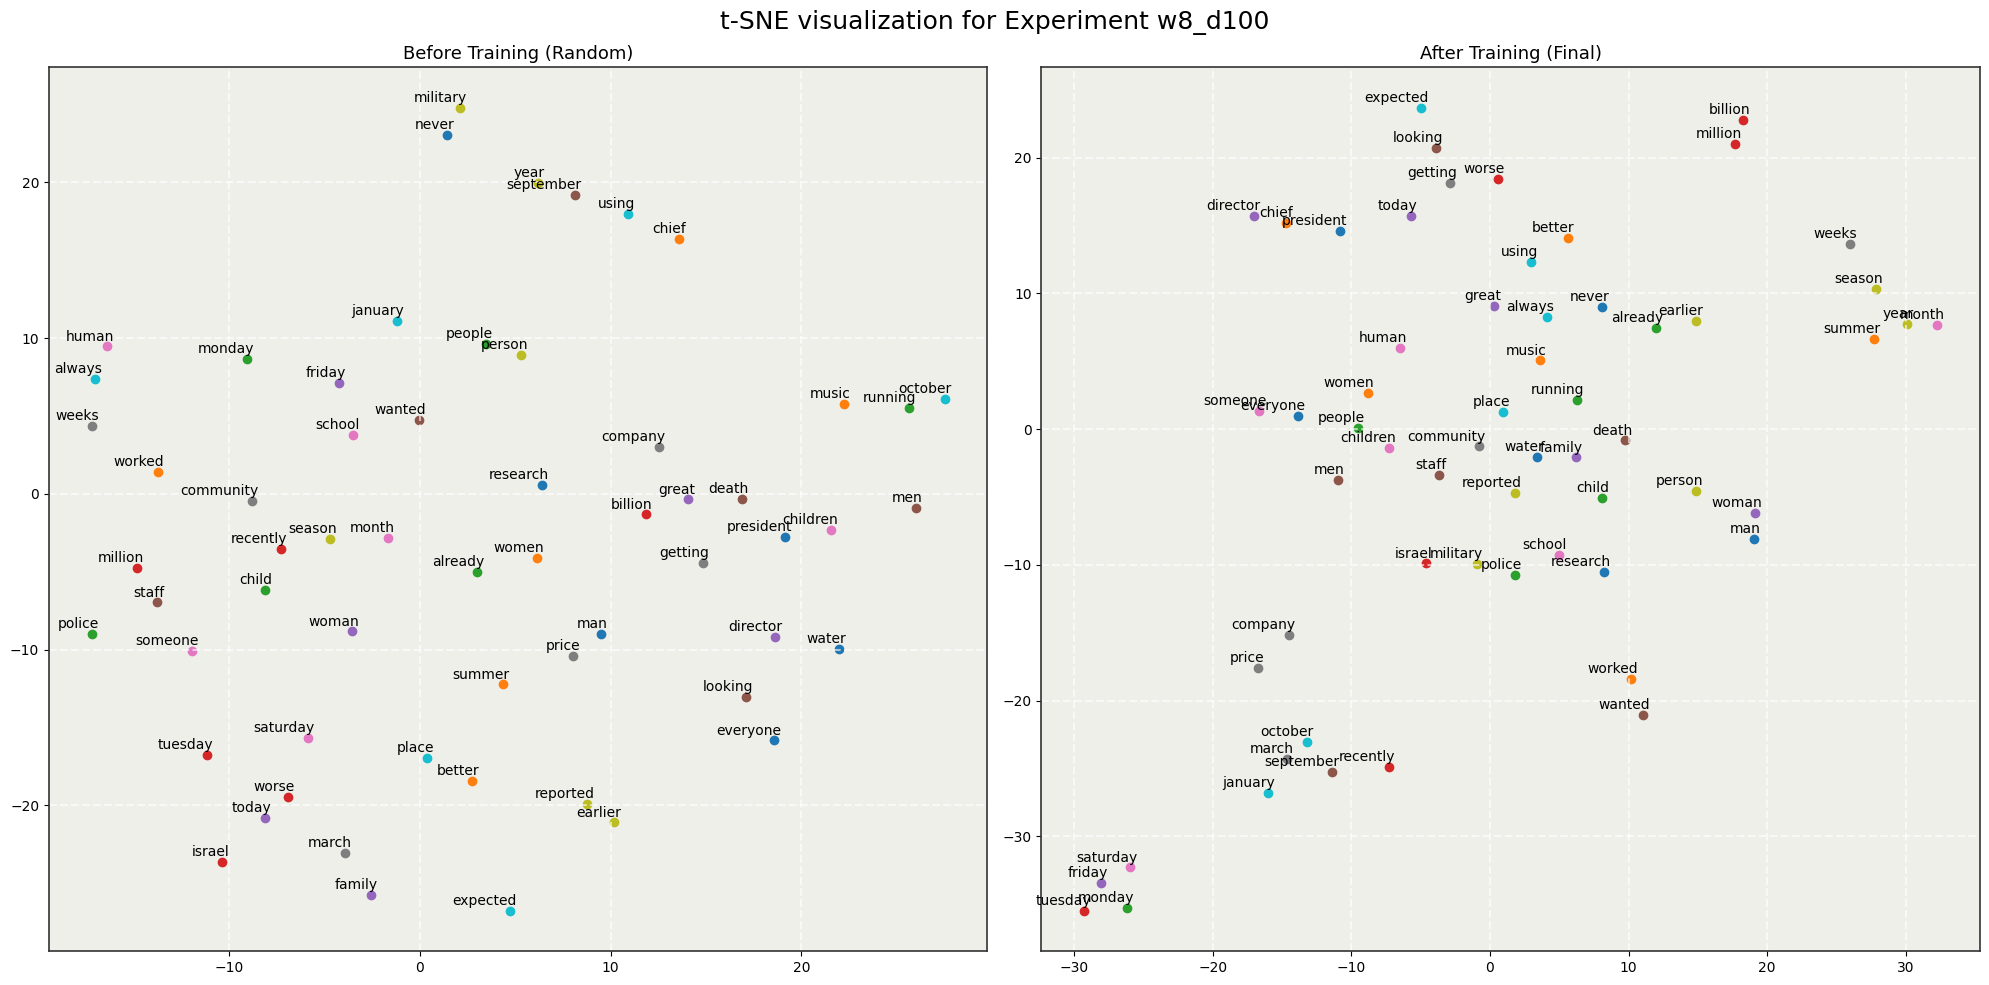

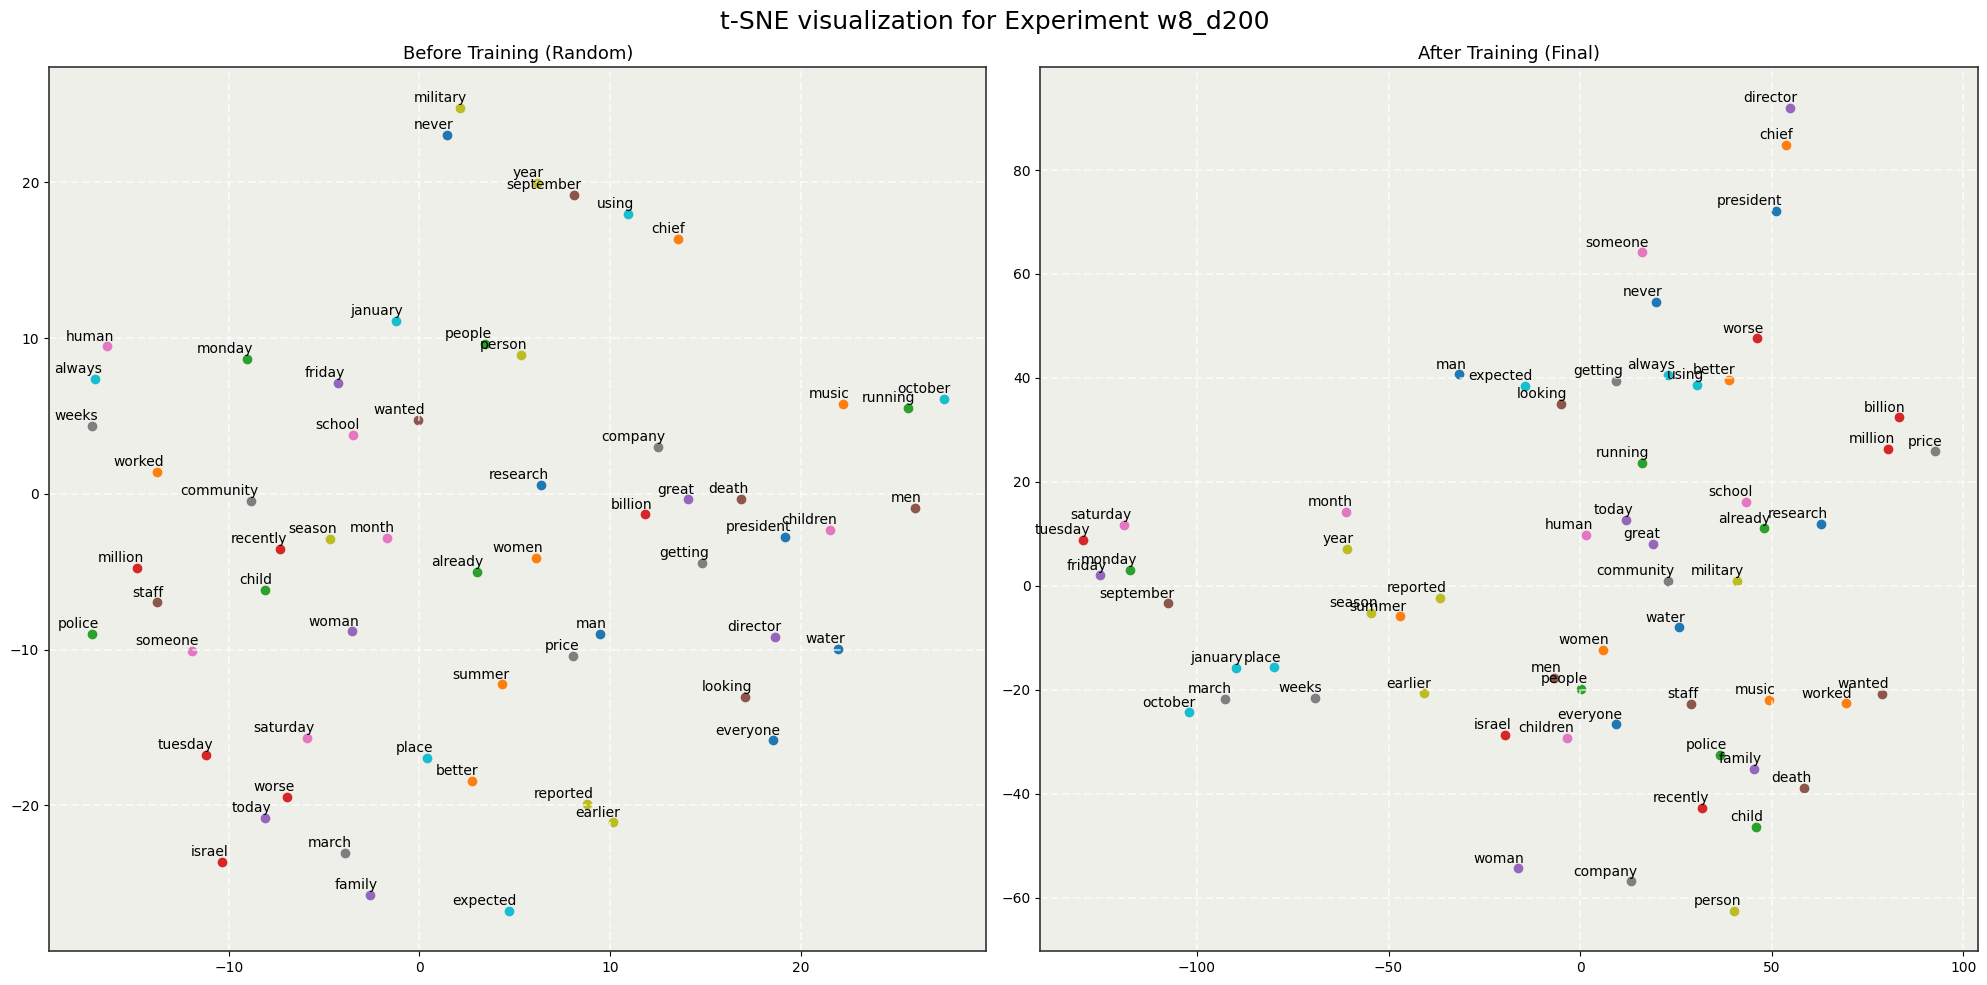

In [23]:
# Initialize a new model and extract random weights
random_model = build_embedding_model(MAX_TOKENS, 100, 2)
random_weights = random_model.get_layer('embedding_layer').get_weights()[0]

for eid in experiment_ids:
    file_path = os.path.join(save_dir, f"embeddings_{eid}.npy")
    trained_embeddings = np.load(file_path)


    visualize_comparison(
        target_words,
        embeddings_before=random_weights,
        embeddings_after=trained_embeddings,
        word_index=word_to_id,
        title=f"t-SNE visualization for Experiment {eid}"
    )

Random Initializations:


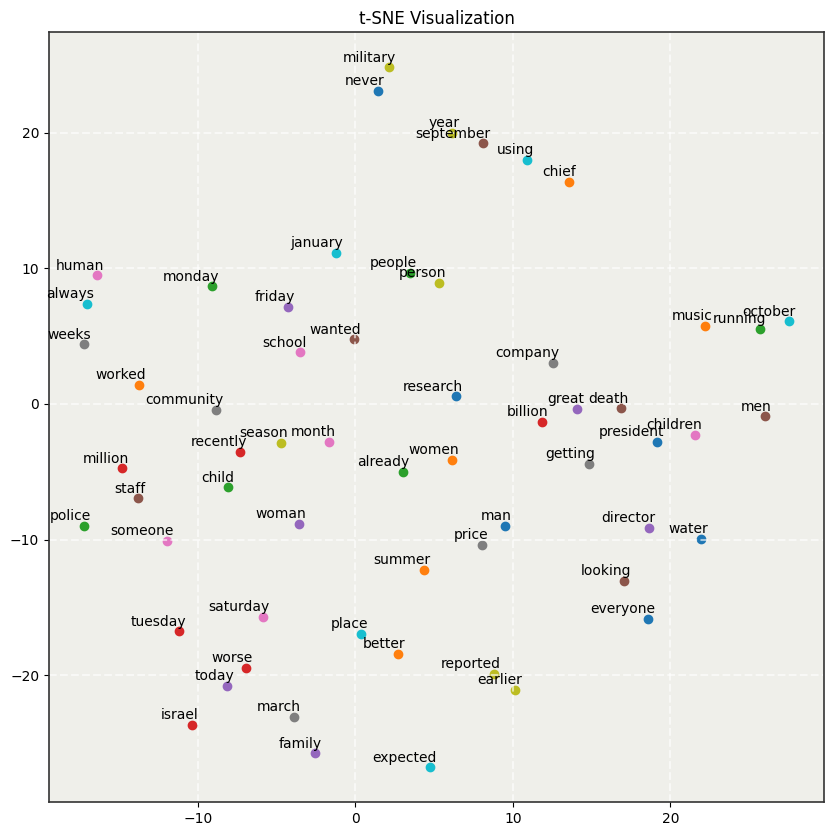

Trained Embeddings:


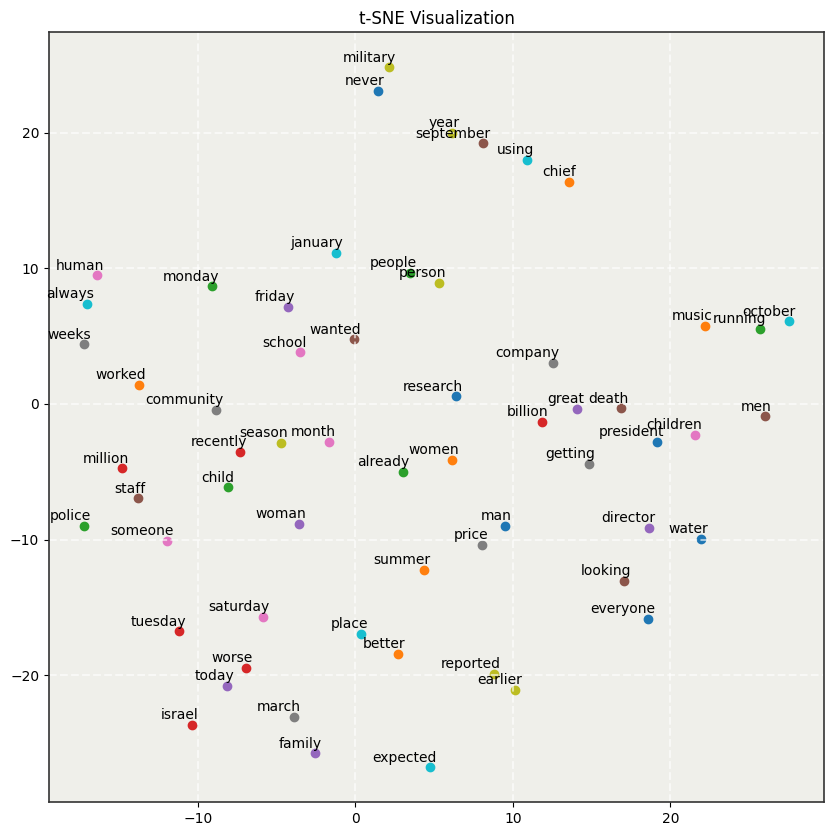

In [ ]:
print("Random Initializations:")
visualize_tsne_embeddings(target_words, random_weights, word_to_id)
plt.show()


print("Trained Embeddings:")
visualize_tsne_embeddings(target_words, trained_embeddings, word_to_id)
plt.show()